In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Load the Breast Cancer Wisconsin (Diagnostic) dataset
breast_cancer = load_breast_cancer()
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target)

print("Dataset loaded successfully!")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nFirst 5 rows of features:")
display(X.head())
print("\nTarget distribution:")
display(y.value_counts())

Dataset loaded successfully!
Features shape: (569, 30)
Target shape: (569,)

First 5 rows of features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target distribution:


,count
1,357
0,212


In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets.
X_train shape: (398, 30)
X_test shape: (171, 30)
y_train shape: (398,)
y_test shape: (171,)


Logistic Regression Accuracy: 0.9415
Logistic Regression Precision: 0.9292
Logistic Regression F1-Score: 0.9545

Logistic Regression Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,56,8
Actual 1,2,105


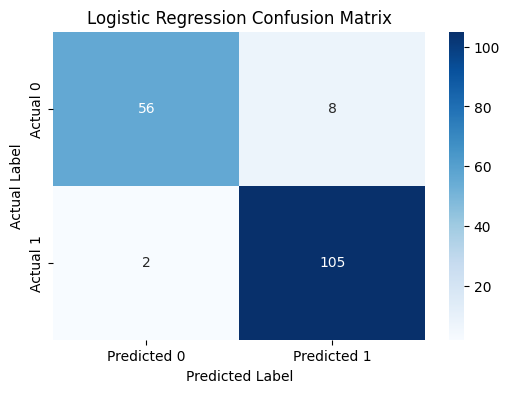

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression Precision: {precision_lr:.4f}")
print(f"Logistic Regression F1-Score: {f1_lr:.4f}")
print("\nLogistic Regression Confusion Matrix:")
display(pd.DataFrame(conf_matrix_lr, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Decision Tree Accuracy: 0.9181
Decision Tree Precision: 0.9346
Decision Tree F1-Score: 0.9346

Decision Tree Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,57,7
Actual 1,7,100


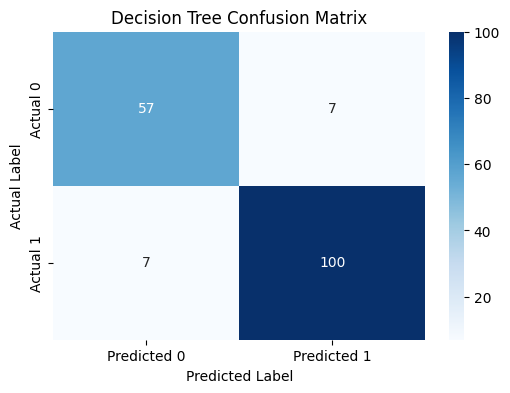

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# Initialize and train the Decision Tree Classifier
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train, y_train)

# Make predictions
y_pred_dtc = dtc_model.predict(X_test)

# Evaluate the model
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
precision_dtc = precision_score(y_test, y_pred_dtc)
f1_dtc = f1_score(y_test, y_pred_dtc)
conf_matrix_dtc = confusion_matrix(y_test, y_pred_dtc)

print(f"Decision Tree Accuracy: {accuracy_dtc:.4f}")
print(f"Decision Tree Precision: {precision_dtc:.4f}")
print(f"Decision Tree F1-Score: {f1_dtc:.4f}")
print("\nDecision Tree Confusion Matrix:")
display(pd.DataFrame(conf_matrix_dtc, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_dtc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Random Forest Accuracy: 0.9357
Random Forest Precision: 0.9444
Random Forest F1-Score: 0.9488

Random Forest Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,58,6
Actual 1,5,102


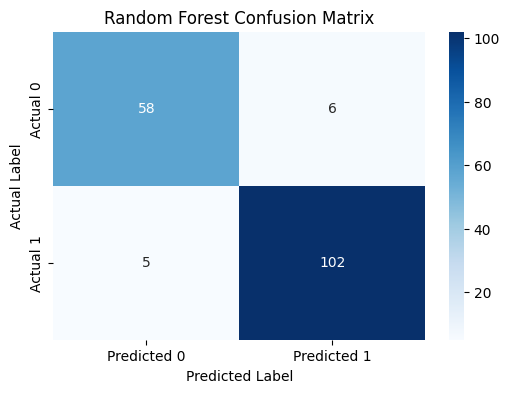

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")
print("\nRandom Forest Confusion Matrix:")
display(pd.DataFrame(conf_matrix_rf, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

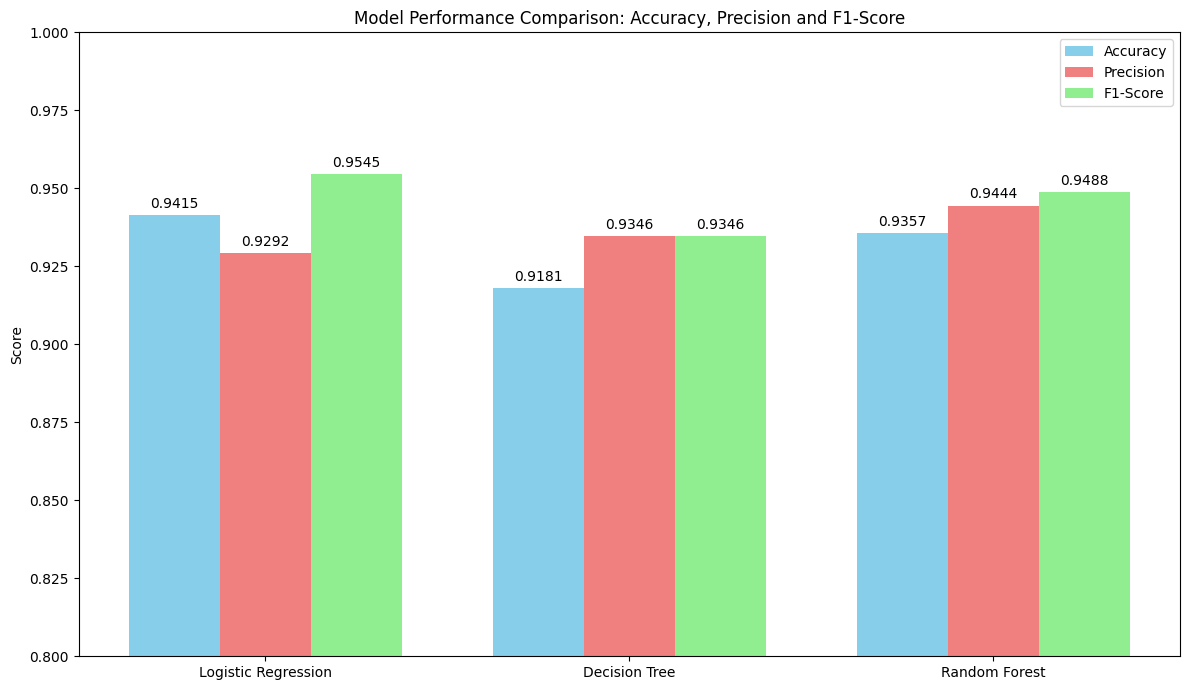

In [ ]:
import numpy as np

# Prepare data for comparison
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [accuracy_lr, accuracy_dtc, accuracy_rf]
precisions = [precision_lr, precision_dtc, precision_rf]
f1_scores = [f1_lr, f1_dtc, f1_rf]

x = np.arange(len(models))  # the label locations
width = 0.25  # Adjusted width for three bars

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width, accuracies, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x, precisions, width, label='Precision', color='lightcoral')
rects3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='lightgreen')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison: Accuracy, Precision and F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim([0.8, 1.0])

def autolabel(rects):
    "Attach a text label above each bar in *rects*, displaying its height."
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()

## Model Performance Comparison: Accuracy, Precision, and F1-Score Explained

This graph displays key performance metrics for each of the three models trained: Logistic Regression, Decision Tree, and Random Forest.

*   **Accuracy (Skyblue bars):** This metric represents the proportion of total correct predictions (both true positives and true negatives) made by the model. It tells us how often the classifier is correct overall. A higher accuracy score means the model is generally better at classifying both classes correctly.

*   **Precision (Lightcoral bars):** This metric focuses specifically on the positive predictions. It tells us, out of all the instances the model predicted as positive, how many were actually positive. High precision indicates a low false positive rate, which is crucial in scenarios where false positives are costly (e.g., misdiagnosing a healthy patient with a disease).

*   **F1-Score (Lightgreen bars):** The F1-score is the harmonic mean of precision and recall. It's a useful metric when you need to balance precision and recall, especially in cases where there's an uneven class distribution. A higher F1-score indicates a better balance between precision and recall.

### Detailed Breakdown of Results:

1.  **Logistic Regression:**
    *   **Accuracy:** 0.9415 (approximately 94.15% of the predictions were correct).
    *   **Precision:** 0.9292 (approximately 92.92% of the positive predictions made by this model were actually correct).
    *   **F1-Score:** 0.9545 (a strong balance between precision and recall).
    This model demonstrates strong overall correctness and a good balance.

2.  **Decision Tree:**
    *   **Accuracy:** 0.9181 (approximately 91.81% of the predictions were correct).
    *   **Precision:** 0.9346 (approximately 93.46% of the positive predictions made by this model were actually correct).
    *   **F1-Score:** 0.9346 (precision and F1-score are very close, indicating moderate recall).
    While its accuracy is slightly lower than Logistic Regression, its precision is quite competitive, suggesting it's good at identifying positive cases when it makes a positive prediction.

3.  **Random Forest:**
    *   **Accuracy:** 0.9357 (approximately 93.57% of the predictions were correct).
    *   **Precision:** 0.9444 (approximately 94.44% of the positive predictions made by this model were actually correct).
    *   **F1-Score:** 0.9488 (a high F1-score, suggesting a good balance of precision and recall).
    The Random Forest model achieves a very high precision and F1-score, making it a robust choice when balancing false positives and false negatives is important. Its accuracy is also very high, close to that of Logistic Regression.

### Key Observations from the Graph:

*   **Overall Performance:** All three models perform remarkably well on this dataset, with accuracy, precision, and F1-scores consistently above 90%.
*   **Highest Accuracy:** **Logistic Regression** has a slight edge in overall accuracy, meaning it classifies the largest proportion of samples correctly.
*   **Highest Precision:** **Random Forest** exhibits the best precision, indicating it has the lowest rate of false positives. This makes it a strong candidate for applications where minimizing incorrect positive predictions is a priority.
*   **Highest F1-Score:** **Logistic Regression** boasts the highest F1-score, suggesting it provides the best overall balance between precision and recall among the models. While Random Forest is very close.
*   **Decision Tree Trade-off:** The Decision Tree has the lowest accuracy, but its precision is higher than Logistic Regression, showcasing a different performance balance. It's less accurate overall but relatively good at its positive predictions.

### Understanding the Trade-offs:

*   **Higher Precision than Accuracy (e.g., Decision Tree compared to Logistic Regression in terms of precision):** When a model has higher precision than its accuracy, it means that while it might miss some actual positive cases (leading to slightly lower overall accuracy), the positive predictions it *does* make are highly reliable. This is often desirable in situations where false positives are very costly, and you want to be sure that when the model says 'positive,' it truly is positive.

*   **Higher Accuracy than Precision (e.g., Logistic Regression has higher accuracy than Decision Tree, but slightly lower precision):** If a model has higher accuracy than precision, it implies that the model is generally correct across both positive and negative classes. However, if its precision is relatively lower, it means that among its positive predictions, there might be a higher proportion of false positives. This could be acceptable if the cost of missing a positive case (false negative) is higher than the cost of a false positive, or if overall correctness is the primary goal.

### Which model to choose as the final model?

The choice of the 'final model' heavily depends on the specific requirements and the cost associated with different types of errors in your application. Given the results:

*   If **overall correctness** (minimizing both false positives and false negatives) is the absolute priority, the **Logistic Regression** model might be slightly preferred due to its marginally higher accuracy and the highest F1-Score.

*   However, if **minimizing false positives** is critical – for example, if incorrectly classifying a healthy patient as having cancer (a false positive) leads to unnecessary stress, further expensive tests, or harmful treatments – then the **Random Forest** model would be a strong candidate. It has the highest precision, meaning that when it predicts a positive outcome, you can have the most confidence in that prediction.

*   The **Logistic Regression** model also stands out with the highest **F1-Score**, which means it offers the best balance between precision and recall. In many real-world scenarios, particularly in medical diagnostics, both false positives and false negatives are important to minimize. A high F1-score indicates a robust model in such contexts.

*   The **Decision Tree** model, while having good precision, has slightly lower overall accuracy, making it a less ideal choice unless there are other factors (like model interpretability) that are highly valued and outweigh the minor performance difference.

In scenarios like breast cancer diagnosis, where a false negative (missing a cancer case) is usually considered more severe than a false positive, one might prioritize a high recall, which would be reflected in a higher F1-score. Based on the metrics shown, the **Logistic Regression** model, with its highest F1-score and very high accuracy, would likely be the most robust choice for a general diagnostic application where balancing both types of errors is important. However, if the absolute minimization of false positives is the primary concern, the **Random Forest** model with its slightly higher precision might be considered.

In conclusion, while all models perform well, the choice between them might depend on whether overall correctness (accuracy), minimizing false positives (precision), or a balance of precision and recall (F1-score) is most critical for your specific application.